In [1]:
import json
import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(5, 5)
sc.settings.verbosity = 3
sc.logging.print_header()
sc.set_figure_params(dpi=100)

Download raw count data from GEO [GSE190604](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE190604) and meta data from Zenodo [5784651](https://zenodo.org/records/5784651). Then convert h5Seurat to h5ad by [extract_meta.R](./extract_meta.R).

In [ ]:
adata = sc.read_10x_mtx("raw", prefix="GSE190604_")
adata.shape

(103805, 36601)

## load meta data and filter cells not in the meta data of the original paper

In [ ]:
meta_df_geo = pd.read_table("raw/GSE190604_cellranger-guidecalls-aggregated-unfiltered.txt.gz")
meta_df_geo.shape

(89751, 4)

In [ ]:
meta_df_geo.head()

,cell_barcode,num_features,feature_call,num_umis
0,GGGAGATAGACCGTTT-1,1,ABCB10-1,216
1,GACGCTGCATTGTCGA-1,1,ABCB10-1,149
2,TTAATCCTCGTGCACG-1,1,ABCB10-1,170
3,ACACGCGTCGACCTAA-1,1,ABCB10-1,131
4,CATCCACCATCGATGT-1,1,ABCB10-1,64


In [ ]:
resting_cell_df = sc.read_h5ad("raw/HuTcellsCRISPRaPerturbSeq_Resting.h5ad", backed='r').obs.copy()
resting_cell_df['stimulation_condition'] = "resting"
stimulated_cell_df = sc.read_h5ad("raw/HuTcellsCRISPRaPerturbSeq_Re-stimulated.h5ad", backed='r').obs.copy()
stimulated_cell_df['stimulation_condition'] = "re-stimulated"
meta_df_zenodo = pd.concat([resting_cell_df, stimulated_cell_df], axis=0)
meta_df_zenodo = meta_df_zenodo[['condition', 'cluster_name', 'CD4.or.CD8', 'gene', 'crispr', 'donor', 'Phase']]

In [ ]:
meta_obs_df = meta_df_zenodo.merge(meta_df_geo, left_index=True, right_on='cell_barcode', how='left').set_index('cell_barcode')
adata_filtered = adata[adata.obs_names.isin(meta_obs_df.index),:].copy()
adata_filtered.obs = pd.concat([adata_filtered.obs, meta_obs_df], axis=1)
adata_filtered


AnnData object with n_obs × n_vars = 57835 × 36601
    obs: 'condition', 'cluster_name', 'CD4.or.CD8', 'gene', 'crispr', 'donor', 'Phase', 'num_features', 'feature_call', 'num_umis'
    var: 'gene_ids', 'feature_types'

In [ ]:
df = adata_filtered.obs[['condition','gene']].groupby(['condition','gene'], observed=True).size().reset_index(name='count')
df

,condition,gene,count
0,Re-stimulated,ABCB10,214
1,Re-stimulated,AKAP12,185
2,Re-stimulated,ALX4,274
3,Re-stimulated,APOBEC3C,301
4,Re-stimulated,APOBEC3D,292
...,...,...,...
135,Resting,TNFRSF9,449
136,Resting,TRAF3IP2,749
137,Resting,TRIM21,513
138,Resting,VAV1,437


/tmp/ipykernel_3194037/32182753.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=7)


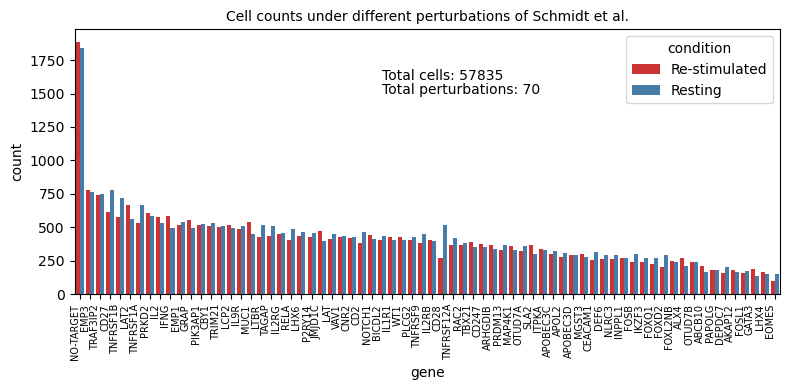

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax = sns.barplot(
    data=df,
    x='gene',
    y='count',
    order=df.groupby('gene', observed=True)['count'].sum().sort_values(ascending=False).index,
    hue='condition',
    palette='Set1',
    ax=ax,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=7)
ax.set_title('Cell counts under different perturbations of Schmidt et al.', fontsize=10)
ax.text(35, 1600, f'Total cells: {df["count"].sum()}')
ax.text(35, 1500, f'Total perturbations: {df["gene"].nunique()}')
plt.tight_layout()
plt.savefig('raw/schmidt_cell_counts_under_different_perturbations.png', dpi=150)

In [ ]:
sc.write("raw/HuTcellsCRISPRaPerturbSeq_filtered.h5ad", adata_filtered)

## load raw data and filter genes not in prior knowledge

In [2]:
radata = sc.read("raw/HuTcellsCRISPRaPerturbSeq_filtered.h5ad")
print(radata)
radata.obs.head().T

AnnData object with n_obs × n_vars = 57835 × 36601
    obs: 'condition', 'cluster_name', 'CD4.or.CD8', 'gene', 'crispr', 'donor', 'Phase', 'num_features', 'feature_call', 'num_umis'
    var: 'gene_ids', 'feature_types'


,AAACCCACAACAAGAT-1,AAACCCACACCCTGTT-1,AAACCCACACTATGTG-1,AAACCCAGTACAGGTG-1,AAACCCAGTATGAGAT-1
condition,Resting,Resting,Resting,Resting,Resting
cluster_name,13: Proliferating (G2/M),10: Proliferating (S),6: CD4 Common,15: GNLY High,6: CD4 Common
CD4.or.CD8,CD8,CD4,Unassigned,CD4,Unassigned
gene,PLCG2,OTUD7B,CD247,PRKD2,IL2RB
crispr,perturbed,perturbed,perturbed,perturbed,perturbed
donor,Donor1,Donor1,Donor2,Donor1,Donor1
Phase,S,G2M,G1,G2M,G1
num_features,1,1,1,1,1
feature_call,PLCG2-2,OTUD7B-1,CD247-1,PRKD2-1,IL2RB-2
num_umis,13,135,44,190,32


In [3]:
padata = radata.copy()
padata.obs = radata.obs.rename(columns={
    'gene': 'perturbation'
})
padata.obs['perturbation'] = padata.obs['perturbation'].map(lambda x: 'control' if x.startswith('NO-TARGET') else x)
padata

AnnData object with n_obs × n_vars = 57835 × 36601
    obs: 'condition', 'cluster_name', 'CD4.or.CD8', 'perturbation', 'crispr', 'donor', 'Phase', 'num_features', 'feature_call', 'num_umis'
    var: 'gene_ids', 'feature_types'

In [4]:
sc.pp.filter_genes(padata, min_cells=50)
sc.pp.filter_cells(padata, min_genes=200)
print(padata.shape)

filtered out 19029 genes that are detected in less than 50 cells
(57835, 17572)


In [5]:
selected_pert_df = padata.obs.groupby(
    ['perturbation', 'condition'], observed=True
).size().reset_index(name='count')
selected_pert_df['count'].min()

102

In [6]:
print(radata, "\n-->\n", padata)

AnnData object with n_obs × n_vars = 57835 × 36601
    obs: 'condition', 'cluster_name', 'CD4.or.CD8', 'gene', 'crispr', 'donor', 'Phase', 'num_features', 'feature_call', 'num_umis'
    var: 'gene_ids', 'feature_types' 
-->
 AnnData object with n_obs × n_vars = 57835 × 17572
    obs: 'condition', 'cluster_name', 'CD4.or.CD8', 'perturbation', 'crispr', 'donor', 'Phase', 'num_features', 'feature_call', 'num_umis', 'n_genes'
    var: 'gene_ids', 'feature_types', 'n_cells'


In [7]:
padata.layers['raw'] = padata.X.copy()
sc.pp.normalize_total(padata, target_sum=1e4)
sc.pp.log1p(padata)
sc.pp.highly_variable_genes(
    padata, n_top_genes=5000, 
    subset=False, flavor='seurat',
)
print(padata.shape)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
(57835, 17572)


In [8]:
nobatch_hvg_v3 = sc.pp.highly_variable_genes(
    padata, n_top_genes=5000, 
    subset=False, flavor='seurat_v3',
    layer='raw', inplace=False
)
padata.var['highly_variable_raw'] = nobatch_hvg_v3['highly_variable']

extracting highly variable genes


In [9]:
batch_hvg_v3 = sc.pp.highly_variable_genes(
    padata, n_top_genes=5000, 
    subset=False, flavor='seurat_v3',
    layer='raw', inplace=False,
    batch_key='condition'
)
padata.var['highly_variable_batch'] = batch_hvg_v3['highly_variable']

extracting highly variable genes


In [10]:
padata.write("preprocessed.h5ad")

## split dataset

In [ ]:
adata = sc.read_h5ad("preprocessed.h5ad")

In [ ]:
np.random.seed(42)
split_df = (
    adata
    .obs[['condition']]
    .copy()
    .reset_index(names='cell')
    .rename(columns={'condition': 'subsplit'})
)
split_df['presplit'] = np.random.choice(
    ['train', 'val', 'test'], 
    size=split_df.shape[0], 
    p=[0.7, 0.1, 0.2], 
    replace=True
)


In [ ]:
# train on Re-stimulated and test on Resting
split_df['split'] = split_df[['subsplit', 'presplit']].apply(
    lambda x: x['presplit'] if x['subsplit'] == 'Re-stimulated' else 'test', axis=1
)
split_df[['cell', 'split', 'subsplit']].to_csv('split_trainonstimulated.csv', index=False)


In [ ]:
pd.read_csv('split_trainonstimulated.csv').groupby(['split', 'subsplit']).size()

split  subsplit     
test   Re-stimulated     5680
       Resting          29382
train  Re-stimulated    19944
val    Re-stimulated     2829
dtype: int64

In [ ]:
# train on Resting and test on Re-stimulated=
split_df['split'] = split_df[['subsplit', 'presplit']].apply(
    lambda x: x['presplit'] if x['subsplit'] == 'Resting' else 'test', axis=1
)
split_df[['cell', 'split', 'subsplit']].to_csv('split_trainonresting.csv', index=False)

In [ ]:
pd.read_csv('split_trainonresting.csv').groupby(['split', 'subsplit']).size()

split  subsplit     
test   Re-stimulated    28453
       Resting           5831
train  Resting          20652
val    Resting           2899
dtype: int64